In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import matplotlib.pyplot as plt
# import pandas as pd

def plot_multi_features(df, features=None, x_axis=None, normalize=False, s=25, alpha=0.75):
    """
    여러 특성(Feature)을 명확히 대비되는 고시인성 색상으로 하나의 그래프에 출력하는 함수
    
    :param df: pandas DataFrame
    :param features: 시각화할 컬럼명 리스트 (None이면 모든 수치형 컬럼 자동 선택)
    :param x_axis: X축으로 사용할 컬럼명 (None이면 데이터의 행 인덱스 사용)
    :param normalize: True 설정 시 0~1(Min-Max) 스케일링 적용
    :param s: 점 크기 (기본값: 25)
    :param alpha: 투명도 (기본값: 0.75)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. 특성 컬럼 선택
    if features is None:
        features = df.select_dtypes(include=['number']).columns.tolist()
        if x_axis in features:
            features.remove(x_axis)

    # 2. 시인성과 대비가 극대화된 원색계열 팔레트 지정 (최대 10개)
    high_contrast_colors = [
        '#E6194B',  # Vibrant Red (빨강)
        '#4363D8',  # Royal Blue (파랑)
        '#3CB44B',  # Bright Green (초록)
        "#EB8841",  # Orange (주황)
        "#EFF13F",  # 노란색
        '#F032E6',  # Magenta (분홍/마젠타)
        '#911EB4',  # Purple (보라)
        '#00D8F6',  # Cyan (하늘/시안)
        '#000000'   # Black (검정)
        "#648000",  # Olive (올리브)
        '#9A6324',  # Brown (갈색)
    ]

    # 3. X축 데이터 설정
    x_data = df[x_axis] if (x_axis and x_axis in df.columns) else df.index
    x_label = x_axis if x_axis else "Index"

    # 4. 데이터 정규화(Min-Max Scaling)
    plot_df = df[features].copy()
    if normalize:
        plot_df = (plot_df - plot_df.min()) / (plot_df.max() - plot_df.min() + 1e-9)

    # 5. 대비가 선명한 색상 및 얇은 검은색 테두리로 시인성 강화
    for i, col in enumerate(features):
        color = high_contrast_colors[i % len(high_contrast_colors)]
        ax.scatter(
            x_data, 
            plot_df[col], 
            label=col, 
            color=color,
            s=s, 
            alpha=alpha, 
            edgecolors='black',  # 테두리를 검은색으로 마감하여 점 경계 구분
            linewidths=0.5
        )

    # 6. 축 및 타이틀 설정
    ax.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax.set_ylabel("Normalized Value (0~1)" if normalize else "Value", fontsize=11, fontweight='bold')
    
    title_suffix = " (Min-Max Normalized)" if normalize else ""
    ax.set_title(f"Multi-Feature Distribution{title_suffix}", fontsize=13, pad=12)

    # 범례 및 그리드
    ax.legend(title="Features", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()



# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
from IPython.display import display

def run_comprehensive_eda(df: pd.DataFrame, features=None, targets=None, plot_show='no' ):
    """
    데이터셋 입력 시 필수 요약 통계 출력 및 핵심 시각화를 실행하는 EDA 자동화 함수
    """
    display(df.head())
    print()

    print("=" * 60)
    print("1. 데이터 기본 구조 및 결측치 요약")
    print("=" * 60)
    print(f"- 데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
    print(f"- 중복 행 수: {df.duplicated().sum()}개")
    print(f"- 결측 총갯수:  {df.isnull().sum().sum()}개  ")
    print(f"- 결측 값있는 행수:  { df.isnull().any(axis=1).sum() }행  ")
    print(f"- 결측 행의 전체 비율:  {( df.isnull().any(axis=1).sum() / len(df)).round(4):.1%}  ")
    if features is not None:
        print(f"- 입력 Feasture의 결측 갯수: {df[features].isnull().sum().sum()}개")
        print(f"- 입력 Feasture의 결측 행수: {df[features].isnull().any(axis=1).sum()}행")    
        print(f"- 입력 Feasture의 결측 행의 전체중 비율: {df[features].isnull().any(axis=1).sum() / len(df):.1%}")  
    
    print("\n[변수별 품질 요약]")
    # 타입, 결측치, 고유값 통합 데이터프레임 생성
    info_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Missing_Count': df.isnull().sum(),
        'Missing_Ratio(%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique_Values': df.nunique()
    })    
    print(info_df)

    # 수정 1: .to_numpy().any() 사용으로 조건문 에러 해결
    if df.isnull().to_numpy().any():
        print("\n[결측치 보유 열 상세]")
        # 수정 2: data_df -> df 변수명 통일
        display(df[df.isnull().any(axis=1)])  #동일: display(df.loc[:, df.isnull().any()])
        
        # 수정 3: != None 대신 is not None 스타일 적용
        if features is not None:
            mask =df[features].isnull().all(axis=1)
            display(df[mask])

        print("\n참고 예제 문장: ")
        print("행삭제: df.dropna(subset={features}).reset_index(drop=True)") 
        print("평균으로 채우기(특정 열만 하려면 컬럼지정): df['Age'] = df['Age'].fillna(df['Age'].mean())")
        print("평균으로 채우기(여러 열 하려면 딕셔너리를 사용): df = df.fillna({'Age': df['Age'].mean(), 'City': 'Unknown'})")
        print("중간값으로 채우기: df['column_name'] = df['column_name'].fillna(df['column_name'].median()) ")
        print("0으로 채우기: df = df.fillna(0) ")
        print("0으로 채우기 특정 열만 0으로 채우려면: df['column_name'] = df['column_name'].fillna(0) ")
        print("빈 문자열로 채우기: df['text_column'] = df['text_column'].fillna('') ")
        print("여러 열을 각각 원하는 값으로 채우기: df = df.fillna({'Name': '', 'Score': 0, 'Category': 'None'}) ")


    # 변수 타입별 분류
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

    print("\n" + "=" * 60)
    print("2. 수치형 및 범주형 변수 기술 통계량")
    print("=" * 60)
    if num_cols:
        print("\n[수치형 변수 요약]")
        print(df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])
    if cat_cols:
        print("\n[범주형 변수 요약]")
        print(df[cat_cols].describe().T[['count', 'unique', 'top', 'freq']])


    # 3. 시각화 단계
    if plot_show == 'yes':
        if features is not None:
            #plot_multi_features(df, features=None, x_axis=None, normalize=False, s=25, alpha=0.75):        
            plot_multi_features(df, features=features)
        else:
            plot_multi_features(df)
        
        # 3-1. 수치형 변수 분포(KDE) 및 이상치(Boxplot)
        if num_cols:
            fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3.5 * len(num_cols)))
            if len(num_cols) == 1:
                axes = np.array([axes])

            for i, col in enumerate(num_cols):
                sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
                axes[i, 0].set_title(f'{col} - Distribution (Skewness: {df[col].skew():.2f})')
                
                sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
                axes[i, 1].set_title(f'{col} - Outliers (Boxplot)')

            plt.tight_layout()
            plt.show()

        # 3-2. 범주형 변수 클래스 분포(Countplot)
        if cat_cols:
            cols_per_row = 2
            rows = (len(cat_cols) + cols_per_row - 1) // cols_per_row
            fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, 3.5 * rows))
            
            axes = np.atleast_1d(axes).flatten()

            for i, col in enumerate(cat_cols):
                sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
                axes[i].set_title(f'{col} - Class Frequencies')
                axes[i].tick_params(axis='x', rotation=30)

            for j in range(len(cat_cols), len(axes)):
                fig.delaxes(axes[j])

            plt.tight_layout()
            plt.show()

        # 3-3. 수치형 피처 간 선형 상관계수 히트맵
        if len(num_cols) > 1:
            plt.figure(figsize=(8, 6))
            sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
            plt.title('Numerical Feature Correlation Heatmap')
            plt.show()

    if features is not None and targets is not None:
        # 7. 분포 시각화
        print("\n[시각화] 변수별 품종 분리도 시각화를 출력합니다...")
        num_features = len(features)
        cols_per_row = 3
        rows = (num_features + cols_per_row - 1) // cols_per_row
        
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 5 * rows))
        if rows == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        for i, col in enumerate(features):
            # 시각화 데이터는 원본 df를 사용하되 타겟별 정상 분리 형태 유지
            # 수정 전 Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 
            #sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], palette='Set2')
            # 수정 후
            sns.boxplot(data=df, x=targets, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], hue=targets, palette='Set2', legend=False)

            axes[i].set_title(f'{col} by {targets}')
            axes[i].set_xlabel('')

        for j in range(num_features, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



1. 데이터 기본 구조 및 결측치 요약
- 데이터 크기: 344행, 7열
- 중복 행 수: 0개
- 결측 총갯수:  19개  
- 결측 값있는 행수:  11행  
- 결측 행의 전체 비율:  3.2%  
- 입력 Feasture의 결측 갯수: 8개
- 입력 Feasture의 결측 행수: 2행
- 입력 Feasture의 결측 행의 전체중 비율: 0.6%

[변수별 품질 요약]
                     Dtype  Missing_Count  Missing_Ratio(%)  Unique_Values
species                str              0              0.00              3
island                 str              0              0.00              3
bill_length_mm     float64              2              0.58            164
bill_depth_mm      float64              2              0.58             80
flipper_length_mm  float64              2              0.58             55
body_mass_g        float64              2              0.58             94
sex                    str             11              3.20              2

[결측치 보유 열 상세]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN



참고 예제 문장: 
행삭제: df.dropna(subset={features}).reset_index(drop=True)
평균으로 채우기(특정 열만 하려면 컬럼지정): df['Age'] = df['Age'].fillna(df['Age'].mean())
평균으로 채우기(여러 열 하려면 딕셔너리를 사용): df = df.fillna({'Age': df['Age'].mean(), 'City': 'Unknown'})
중간값으로 채우기: df['column_name'] = df['column_name'].fillna(df['column_name'].median()) 
0으로 채우기: df = df.fillna(0) 
0으로 채우기 특정 열만 0으로 채우려면: df['column_name'] = df['column_name'].fillna(0) 
빈 문자열로 채우기: df['text_column'] = df['text_column'].fillna('') 
여러 열을 각각 원하는 값으로 채우기: df = df.fillna({'Name': '', 'Score': 0, 'Category': 'None'}) 

2. 수치형 및 범주형 변수 기술 통계량

[수치형 변수 요약]
                          mean         std     min      50%     max
bill_length_mm       43.921930    5.459584    32.1    44.45    59.6
bill_depth_mm        17.151170    1.974793    13.1    17.30    21.5
flipper_length_mm   200.915205   14.061714   172.0   197.00   231.0
body_mass_g        4201.754386  801.954536  2700.0  4050.00  6300.0

[범주형 변수 요약]
        count unique     top freq
species   34

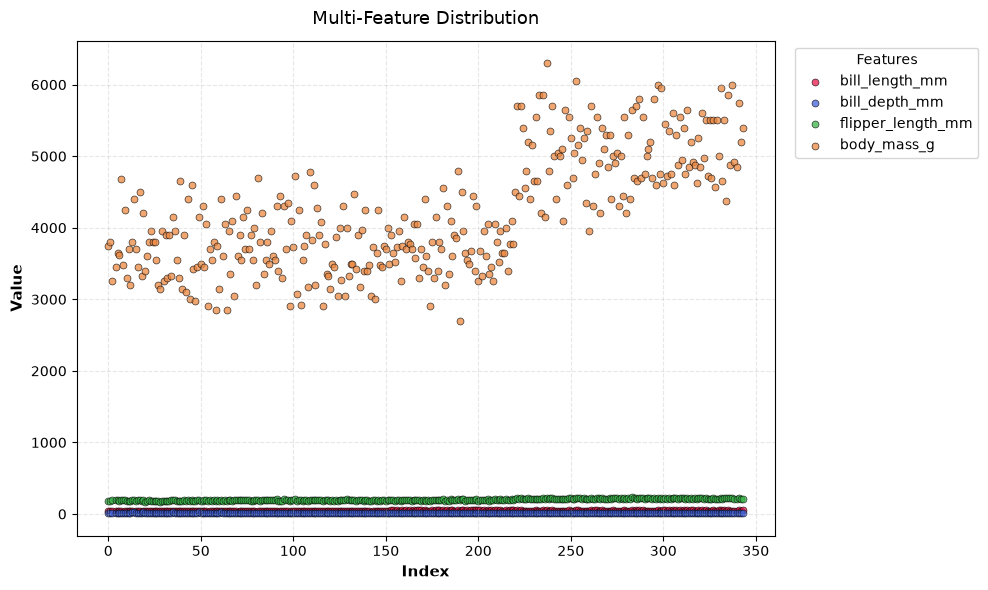

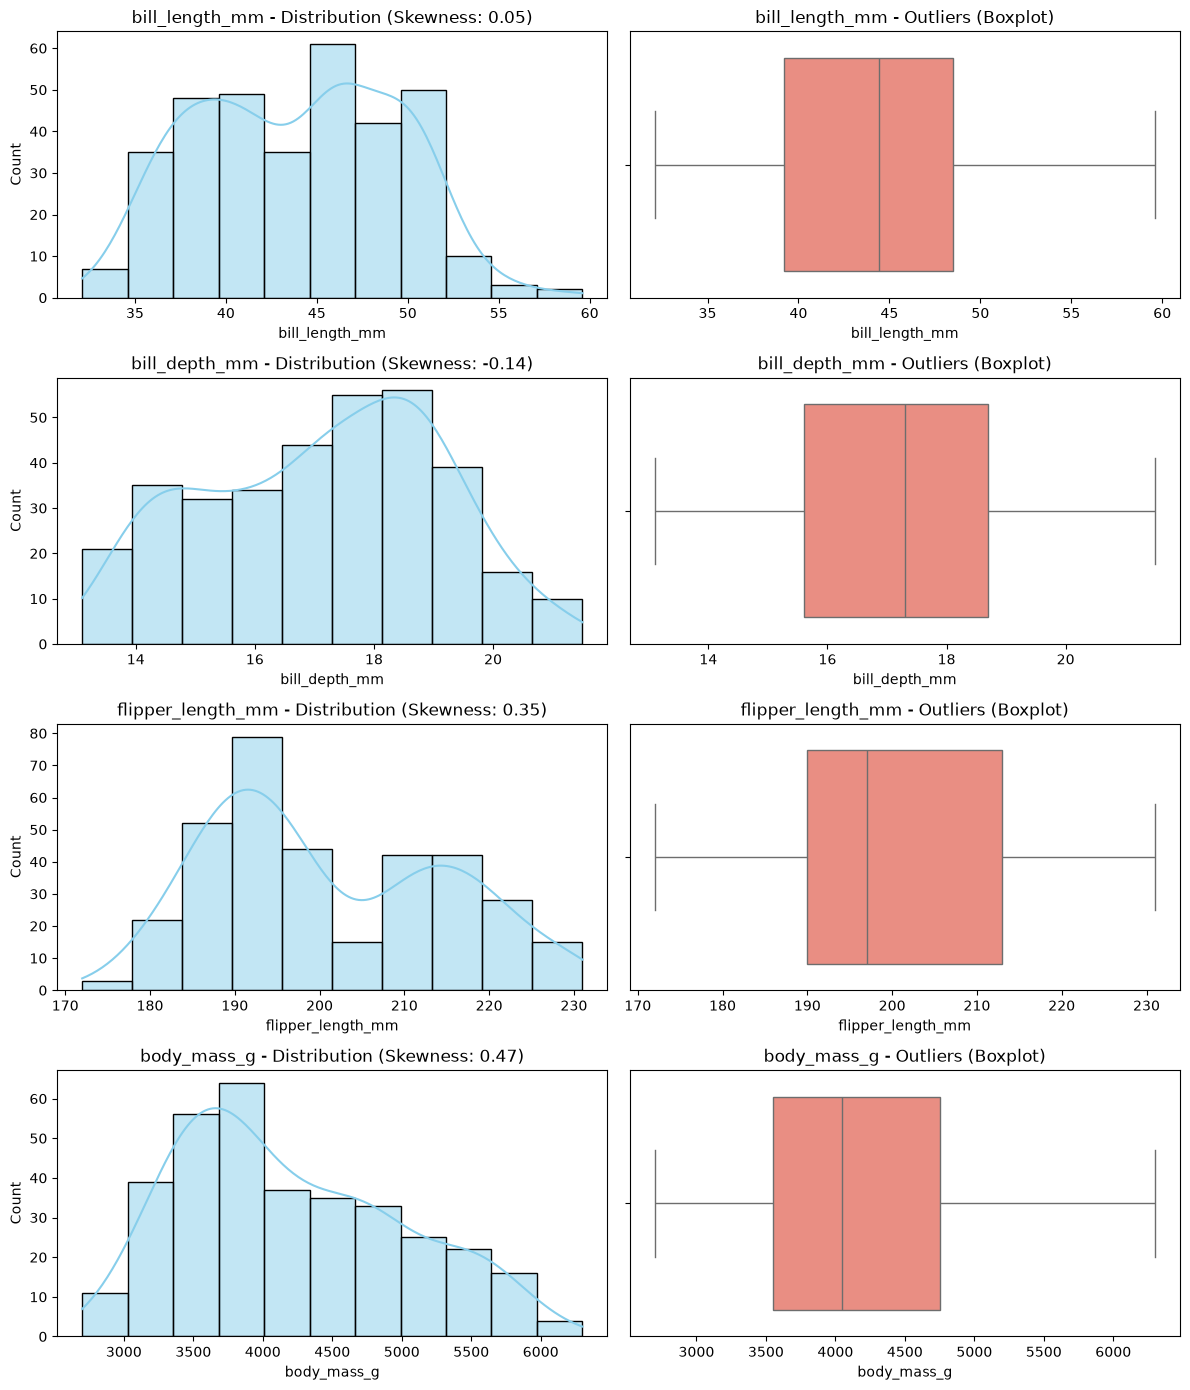

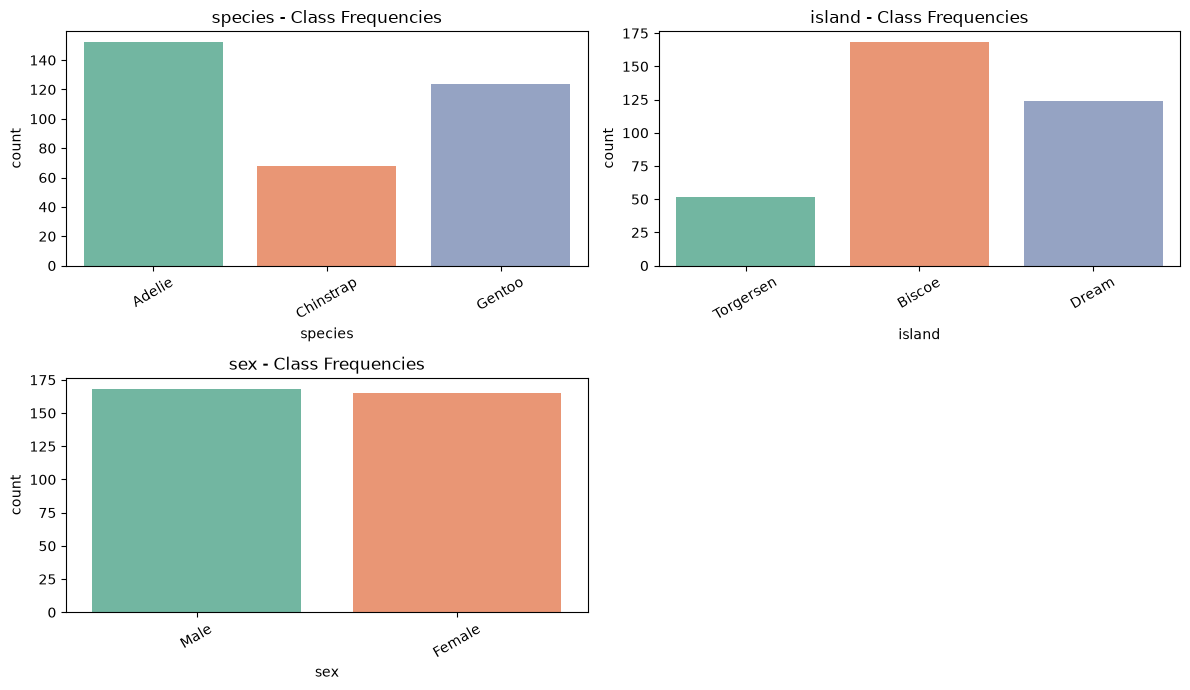

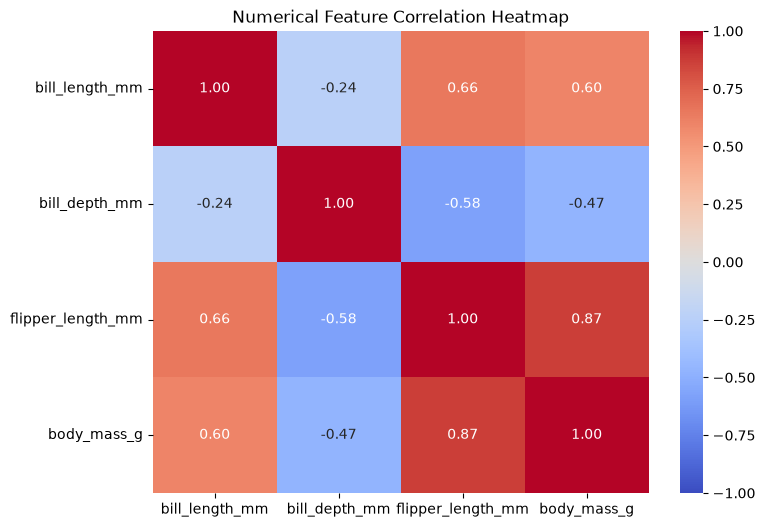


[시각화] 변수별 품종 분리도 시각화를 출력합니다...


ValueError: Length of list vectors must match length of `data` when both are used, but `data` has length 344 and the vector passed to `x` has length 1.

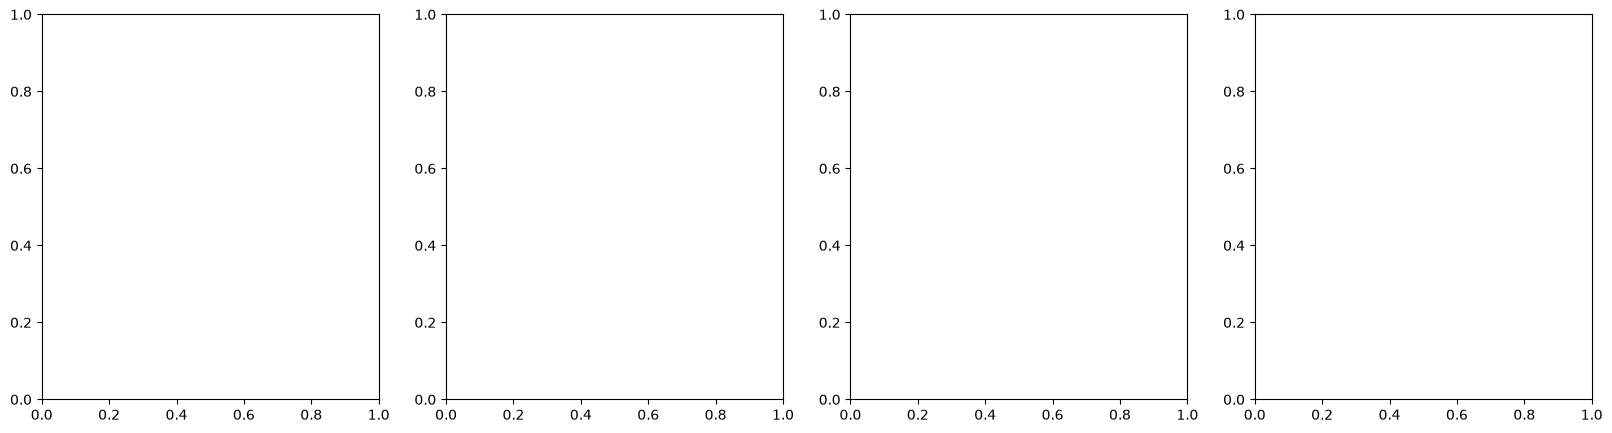

In [142]:
run_comprehensive_eda(data_df, features=FEATURES_COLUMNS, targets=Target_column, plot_show = 'yes')

# Palmer Penguins 결정 트리 

화면에 제시된 짧은 기본 코드를 **아래 빈 코드 셀에 직접 타이핑**하며 복습합니다.

- 예측 대상: `species` 3개 클래스 (`Adelie`, `Chinstrap`, `Gentoo`)


In [140]:
# Q1. 데이터 준비
# 아래 순서대로 코드를 직접 입력하세요.
#
# 1) pathlib.Path, matplotlib.pyplot, pandas를 import합니다.
# 2) accuracy_score, train_test_split,
#    DecisionTreeClassifier, plot_tree를 import합니다.
# 3) FEATURE_COLUMNS에 아래 4개 열을 리스트로 적습니다.
#    bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
# 4) pd.read_csv(Path("penguins.csv"))로 데이터를 읽습니다.
# 5) 위 4개 열과 species의 결측치를 dropna()로 제거합니다.
# 6) X에는 4개 입력 열, y에는 species를 넣습니다.
# 7) X.shape, y.shape, sorted(y.unique())를 print()로 확인합니다.
#
# 개념 질문: X와 y는 각각 무엇을 뜻하나요?
# X: ____________________ / y: ____________________

# 이 아래에 코드를 직접 입력하세요.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


data_df = pd.read_csv(Path("penguins.csv"))
display(data_df.head())
Target_column = ['species']
FEATURES_COLUMNS = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm','body_mass_g']
#run_comprehensive_eda(data_df)
#run_comprehensive_eda(data_df, features_cols=FEATURES_COLUMNS)

data_clean_df = data_df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']).reset_index(drop=True)
X = data_clean_df[FEATURES_COLUMNS]
y = data_clean_df[Target_column]
print(X.shape)
print(y.shape)
#print(sorted(y.unique()))
print(sorted(y['species'].unique()))


      

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


(342, 4)
(342, 1)
['Adelie', 'Chinstrap', 'Gentoo']


## Q2. train / test 나누기

아래 코드를 빈 셀에 직접 타이핑하고 Train/Test 행 수를 확인하세요.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
```

**개념 질문**: 왜 전체 데이터를 한꺼번에 학습에 쓰지 않을까요? `____________________________`


In [77]:
# Q2 코드를 이 아래에 직접 입력하세요.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)
print("Train: ", X_train.shape, y_train.shape )
print("Test: ", X_test.shape, y_test.shape)

Train:  (273, 4) (273, 1)
Test:  (69, 4) (69, 1)


## Q3. 결정 트리 만들기

`max_depth` 숫자 한 곳을 직접 타이핑합니다.

```python
tree_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
)

print(tree_depth3)
```

**개념 질문**: `max_depth=3`은 무엇을 제한하나요? `____________________________`


In [78]:
# Q3 코드를 이 아래에 직접 입력하세요.
tree_depth3 = DecisionTreeClassifier( max_depth=3, random_state=42,)

print(tree_depth3)

DecisionTreeClassifier(max_depth=3, random_state=42)


## Q4. 학습하고 예측하기

핵심 메서드 이름 `fit`, `predict`를 직접 타이핑합니다.

```python
tree_depth3.fit(X_train, y_train)
y_pred_depth3 = tree_depth3.predict(X_test)

print("실제 species:", y_test.iloc[:5].tolist())
print("예측 species:", y_pred_depth3[:5].tolist())
```

**개념 질문**: `fit()`과 `predict()`의 역할은 어떻게 다른가요? `____________________________`


In [86]:
# Q4 코드를 이 아래에 직접 입력하세요.

tree_depth3.fit(X_train, y_train)
y_pred_depth3 = tree_depth3.predict(X_test)

print("예측 species: ", y_pred_depth3[:5].tolist() )  #np arrary
print("실제 species: ", y_test.iloc[:5,0].tolist() ) #DataFrame




예측 species:  ['Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap']
실제 species:  ['Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap']


In [ ]:
# Q5. 정확도 확인
# 아래 코드를 직접 입력해 정답 수와 accuracy를 확인하세요.
#
# accuracy_depth3 = accuracy_score(y_test, y_pred_depth3)
# correct_depth3 = int((y_pred_depth3 == y_test).sum())
# print(f"정답 수: {correct_depth3} / {len(y_test)}")
# print(f"accuracy: {accuracy_depth3:.3f} ({accuracy_depth3:.1%})")
#
# 개념 질문: accuracy가 0.986이라면 무슨 뜻인가요?
# 답: ________________________________________________

# 이 아래에 코드를 직접 입력하세요.
accuracy_depth3 = accuracy_score(y_test, y_pred_depth3)
correct_depth3 = int((y_pred_depth3 == np.array(y_test)).sum())

print(f"정답수:  {correct_depth3} / {len(y_test)} ")
print(f"accuracy:  {accuracy_depth3:.3f} ({accuracy_depth3:.1%})")

정답수:  1737 / 69 
accuracy:  0.986 (98.6%)


## Q6. 트리의 첫 질문 읽기

아래 코드를 직접 타이핑해 트리를 그리고 첫 질문을 확인하세요.

```python
plt.figure(figsize=(16, 8))
plot_tree(
    tree_depth3,
    feature_names=FEATURE_COLUMNS,
    class_names=tree_depth3.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.show()

root_feature = FEATURE_COLUMNS[tree_depth3.tree_.feature[0]]
root_threshold = tree_depth3.tree_.threshold[0]
print(f"첫 질문: {root_feature} <= {root_threshold:.1f}?")
```

**개념 질문**: 이 트리가 가장 먼저 확인한 feature는 무엇인가요? `____________________________`


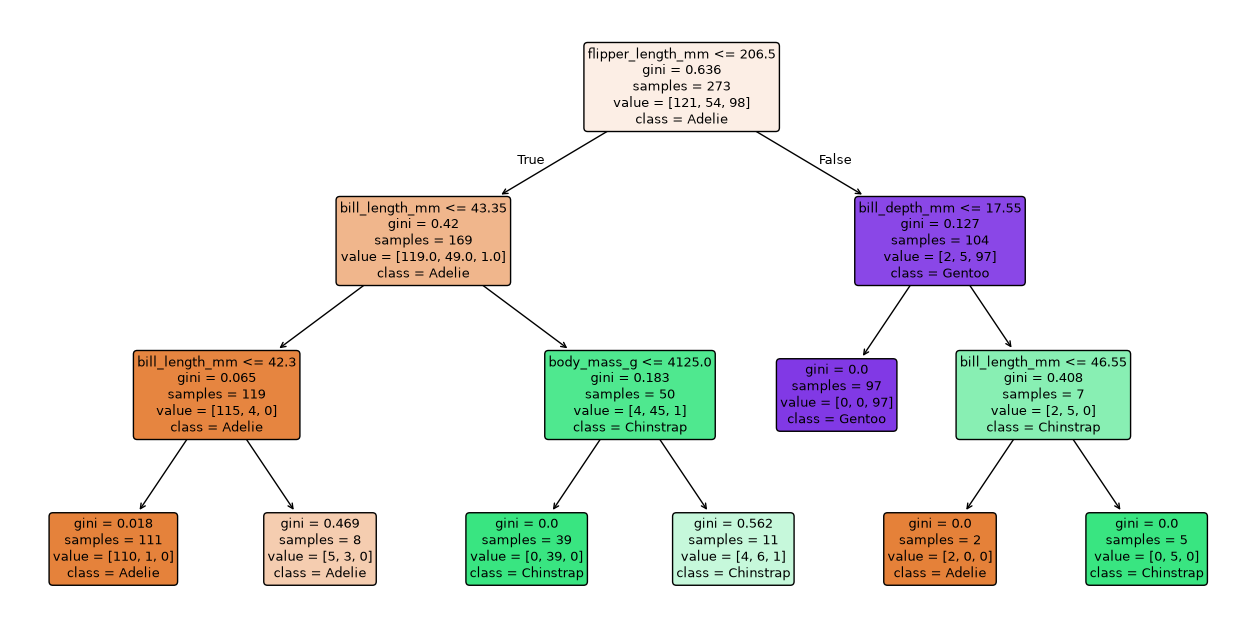

첫 질문: flipper_length_mm <= 206.5?


In [106]:
# Q6 코드를 이 아래에 직접 입력하세요.
plt.figure(figsize=(16,8))
plot_tree( tree_depth3, 
          feature_names=FEATURES_COLUMNS, 
          class_names=tree_depth3.classes_,
          filled=True,
          rounded=True,
          fontsize=9,
        
          )
plt.show()

root_feature = FEATURES_COLUMNS[tree_depth3.tree_.feature[0]]
root_threshold = tree_depth3.tree_.threshold[0]

print(f"첫 질문: {root_feature} <= {root_threshold:.1f}?")


## Q7. max_depth=3과 5를 작게 비교하기

깊이만 `5`로 바꾸어 같은 과정을 한 번 더 직접 타이핑합니다.

```python
tree_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_depth5.fit(X_train, y_train)
y_pred_depth5 = tree_depth5.predict(X_test)
accuracy_depth5 = accuracy_score(y_test, y_pred_depth5)

print(f"max_depth=3: {accuracy_depth3:.3f}")
print(f"max_depth=5: {accuracy_depth5:.3f}")
```

**개념 질문**: 한 번의 결과만 보고 “깊을수록 항상 좋다”고 말할 수 있을까요? `예 / 아니오` — 이유: `____________________________`


In [103]:
# Q7 코드를 이 아래에 직접 입력하세요.
tree_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_depth5.fit(X_train, y_train)
y_pred_depth5 = tree_depth5.predict(X_test)
accuracy_depth5 = accuracy_score(y_test, y_pred_depth5)

print(f"max_depth=3: {accuracy_depth3:.3f}")
print(f"max_depth=5: {accuracy_depth5:.3f}")

max_depth=3: 0.986
max_depth=5: 1.000
